In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv(
    "urlset.csv",
    encoding="latin1",
    low_memory=False,
    on_bad_lines="skip"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (96005, 14)


In [3]:
df.head()

,domain,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,10000000,1.0,0.0,18.0,107.611111,107.277778,0.0,0.0,0.0,0.0,0.8,0.795729,1.0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,10000000,0.0,0.0,11.0,150.636364,152.272727,0.0,0.0,0.0,0.0,0,0.768577,1.0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,10000000,0.0,0.0,14.0,73.500000,72.642857,0.0,0.0,0.0,0.0,0,0.726582,1.0
3,mail.printakid.com/www.online.americanexpress....,10000000,0.0,0.0,6.0,562.000000,590.666667,0.0,0.0,0.0,0.0,0,0.85964,1.0
4,thewhiskeydregs.com/wp-content/themes/widescre...,10000000,0.0,0.0,8.0,29.000000,24.125000,0.0,0.0,0.0,0.0,0,0.748971,1.0


In [4]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['domain', 'ranking', 'mld_res', 'mld.ps_res', 'card_rem', 'ratio_Rrem', 'ratio_Arem', 'jaccard_RR', 'jaccard_RA', 'jaccard_AR', 'jaccard_AA', 'jaccard_ARrd', 'jaccard_ARrem', 'label']


In [5]:
print("Data Types:")
print(df.dtypes)

Data Types:
domain            object
ranking           object
mld_res           object
mld.ps_res        object
card_rem         float64
ratio_Rrem       float64
ratio_Arem       float64
jaccard_RR       float64
jaccard_RA       float64
jaccard_AR       float64
jaccard_AA       float64
jaccard_ARrd      object
jaccard_ARrem     object
label            float64
dtype: object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96005 entries, 0 to 96004
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   domain         96005 non-null  object 
 1   ranking        95953 non-null  object 
 2   mld_res        95935 non-null  object 
 3   mld.ps_res     95924 non-null  object 
 4   card_rem       95923 non-null  float64
 5   ratio_Rrem     95923 non-null  float64
 6   ratio_Arem     95923 non-null  float64
 7   jaccard_RR     95922 non-null  float64
 8   jaccard_RA     95921 non-null  float64
 9   jaccard_AR     95920 non-null  float64
 10  jaccard_AA     95919 non-null  float64
 11  jaccard_ARrd   95919 non-null  object 
 12  jaccard_ARrem  95917 non-null  object 
 13  label          95913 non-null  float64
dtypes: float64(8), object(6)
memory usage: 10.3+ MB


In [7]:
df.sample(5, random_state=42)

,domain,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
88609,keir.net/bosskey.html,10000000,1.0,0.0,3.0,164.666667,179.666667,0.00000,0.001808,0.000000,0.001815,0.866667,0.750847,0.0
34507,besdez.net/S7XIde/webscr_prim.php?YmVzZGV6Lm5l...,10000000,0.0,0.0,5.0,87.400000,92.000000,0.00000,0.000000,0.000000,0.000000,0,0.853306,1.0
53443,members.ozemail.com.au/~ksengs/,10000000,1.0,1.0,1.0,8.000000,7.000000,0.00000,0.000000,0.000000,0.000000,0.733333,0.5,0.0
18455,esxcc.com/js/index.htm?us.battle.net/login/en/...,10000000,0.0,0.0,10.0,151.300000,148.800000,0.00000,0.000000,0.000000,0.000000,0,0.759086,1.0
58808,www.maths.lse.ac.uk/Personal/martin/,13648,1.0,0.0,3.0,105.666667,111.333333,0.00289,0.005525,0.002994,0.005714,0.6,0.699739,0.0


In [8]:
df.describe()

,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,label
count,95923.000000,95923.000000,95923.000000,95922.000000,95921.000000,95920.000000,95919.000000,95913.000000
mean,4.580498,135.255201,138.544211,0.005030,0.003787,0.003378,0.003661,0.499453
std,4.466073,160.988895,175.480485,0.311308,0.024815,0.024011,0.028492,0.500002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,43.000000,39.666667,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,104.000000,103.333333,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,174.142857,178.292857,0.000000,0.000000,0.000000,0.000000,1.000000
max,187.333333,5507.000000,6097.000000,96.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.isnull().sum()

domain            0
ranking          52
mld_res          70
mld.ps_res       81
card_rem         82
ratio_Rrem       82
ratio_Arem       82
jaccard_RR       83
jaccard_RA       84
jaccard_AR       85
jaccard_AA       86
jaccard_ARrd     86
jaccard_ARrem    88
label            92
dtype: int64

In [10]:
df.duplicated().sum()

1

In [11]:
df["domain"].duplicated().sum()

2

In [12]:
df["label"].value_counts()

label
0.0    48009
1.0    47904
Name: count, dtype: int64

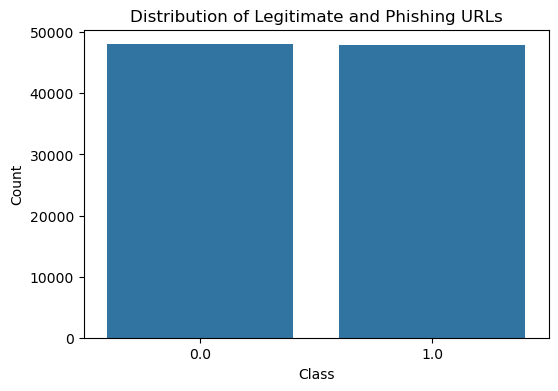

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(x="label", data=df)

plt.title("Distribution of Legitimate and Phishing URLs")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [14]:
df["url_length"] = df["domain"].astype(str).apply(len)

df[["domain", "url_length"]].head()

,domain,url_length
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,225
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,81
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,177
3,mail.printakid.com/www.online.americanexpress....,60
4,thewhiskeydregs.com/wp-content/themes/widescre...,116


In [15]:
df.groupby("label")["url_length"].mean()

label
0.0    36.803995
1.0    92.170591
Name: url_length, dtype: float64

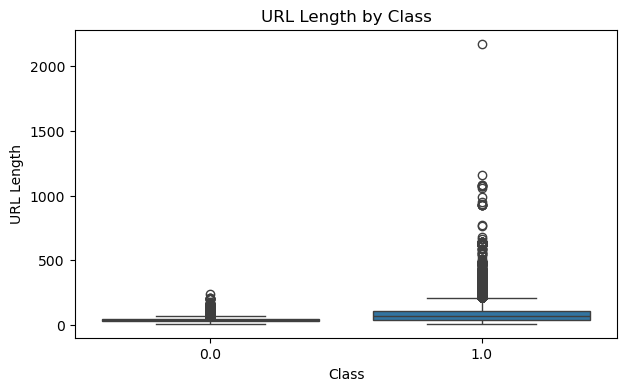

In [16]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    x="label",
    y="url_length",
    data=df
)

plt.title("URL Length by Class")
plt.xlabel("Class")
plt.ylabel("URL Length")

plt.show()

In [17]:
def count_special_characters(url):
    return len(re.findall(r'[^A-Za-z0-9]', str(url)))

df["special_char_count"] = df["domain"].apply(count_special_characters)

df["special_char_frequency"] = (
    df["special_char_count"] / df["domain"].str.len()
)

df[["domain", "special_char_count", "special_char_frequency"]].head()

,domain,special_char_count,special_char_frequency
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,32,0.142222
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,15,0.185185
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,19,0.107345
3,mail.printakid.com/www.online.americanexpress....,8,0.133333
4,thewhiskeydregs.com/wp-content/themes/widescre...,13,0.112069


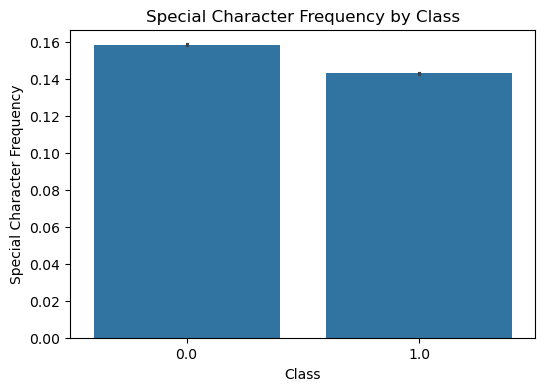

In [20]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x="label",
    y="special_char_frequency",
    data=df
)

plt.title("Special Character Frequency by Class")
plt.xlabel("Class")
plt.ylabel("Special Character Frequency")

plt.show()

In [19]:
print("Shape before cleaning:", df.shape)

df = df.dropna(subset=["label"])

print("Shape after cleaning:", df.shape)
print("\nMissing labels:", df["label"].isnull().sum())

Shape before cleaning: (96005, 17)
Shape after cleaning: (95913, 17)

Missing labels: 0
